# Tentang Notebook Modul 02: Univariate Numerical Analysis

## Target Pembelajaran

* Menjelaskan karakteristik setiap variabel numerik secara individual menggunakan ukuran pemusatan dan penyebaran, sebelum masuk ke analisis hubungan antar variabel
* Membedakan mean dan median sebagai indikator awal skewness, serta menjelaskan mengapa keduanya bisa berbeda jauh pada data tertentu
* Membaca bentuk distribusi (histogram/KDE) untuk mengidentifikasi pola skewness (simetris, right-skewed, left-skewed) dan multimodalitas
* Menghitung IQR dan menggunakan aturan pagar (1.5 × IQR) untuk mendeteksi outlier statistik melalui boxplot
* Menerapkan penilaian domain/kontekstual untuk menemukan rentang nilai yang tidak masuk akal, di luar sekadar deteksi statistik
* Merangkai seluruh temuan (mean, median, std, skewness, bentuk distribusi, outlier) menjadi satu narasi interpretasi yang utuh untuk setiap variabel numerik — bukan sekadar melaporkan angka mentah

## Isi Materi

| Sub-bab  | Topik                                                                                      |
| -------- | ------------------------------------------------------------------------------------------ |
| **2.1**  | Kedudukan univariate analysis dalam alur EDA — kenapa harus dianalisis satu per satu dulu  |
| **2.2**  | Ukuran pemusatan data: mean dan median (serta sensitivitasnya terhadap outlier)            |
| **2.3**  | Ukuran penyebaran data: standard deviation, variance, min/max, range, quantile, IQR        |
| **2.4**  | `describe()` sebagai ringkasan cepat — dan kenapa tidak pernah cukup sendirian             |
| **2.5**  | Distribusi data: histogram dan KDE                                                         |
| **2.6**  | Skewness — mengukur asimetri distribusi (simetris, right-skewed, left-skewed)              |
| **2.7**  | Multimodal distribution — indikasi tercampurnya subpopulasi                                |
| **2.8**  | IQR dan deteksi outlier via boxplot (anatomi boxplot, aturan pagar)                        |
| **2.9**  | Rentang nilai tidak masuk akal (implausible value ranges) — penilaian berbasis domain      |
| **2.10** | Interpretasi statistik deskriptif secara holistik — menyusun narasi karakteristik variabel |


## Goals

Output akhir modul: mampu menjawab pertanyaan "Bagaimana karakteristik setiap variabel numerik ini — pusat, sebaran, bentuk, dan kewajarannya?" untuk dataset apa pun yang Anda hadapi.

# Bagian 1 — Penjelasan

## 2.1 Kedudukan Univariate Analysis dalam Alur EDA

Analsis univariate: tahap dimana setiap variabel numerik diperiksa secara terpisah, tanpa memperhitungkan variabel lain terlebiih dahulu. Terdapat alasan metodologis di balik urutan ini:
* Memahami karakteristik satu variabel adalah prasyarat untuk memahami hubungan dua variabel. Anda tidak dapat menginterpretasikan korelasi antara usia dan gaji secara bermakna jika Anda belum tahu bagaimana distribusi masing-masing.
* Banyak keputusan pemodelan — seperti perlunya transformasi logaritmik, penanganan outlier, atau pemilihan metrik pemusatan yang tepat — ditentukan pada tahap ini, jauh sebelum proses bivariate maupun modeling.
* Univariate analysis berfungsi sebagai baseline untuk mendeteksi anomali pada tahap-tahap berikutnya: jika Anda tidak tahu bagaimana bentuk "normal" dari sebuah variabel, Anda tidak akan mampu mengenali penyimpangannya.

## 2.2 Ukuran Pemusatan Data (Measures of Central Tendency)

ukuran pemusatan menjawab "Disekitar nilai apa data ini cenderung berkumpul?"

* Mean: jumlah seluruh data dibagi banyaknya observasi - Mean sangat berpengaruh terhadap outlier, karena setiap observasi ikut mempengaruhi penjumlahan secara linear.
* Median (nilai tengah): nilai yang dibagi 2 bagian setelah diurutkan, Median bersifat robust terhadap outlier, karena hanya bergantung pada posisi, bukan besaran nilai.

Prinsip fundamental:
* Perbedaan antara mean dan median adalah indikator awal skewness.
* Jika mean jauh lebih besar dari median, data cenderung condong ke kanan (right-skewed)
* Jika mean jauh lebih kecil dari median, data condong ke kiri (left-skewed)

## 2.3 Ukuran Penyebaran Data (Measures of Dispersion)

Dua variabel bisa memiliki mean yang identik tetapi sebaran data sangat berbeda

> ukuran penyebaran menjawab " seberapa jauh data tersebar dari pusatnya"

* Standar deviasi: rata rata jarak setiap observasi terhadap mean, dalam satuan yang sama pada data asli, Semakin besar std semakin heterogen datanya
* Variance — kuadrat dari standard deviation. Jarang diinterpretasikan langsung karena satuannya berubah (kuadrat), tetapi penting secara matematis sebagai dasar perhitungan std.
* Min dan Max — batas bawah dan atas dari data. Berguna untuk pemeriksaan cepat terhadap rentang nilai yang masuk akal (dibahas di 2.9).
* Range — selisih antara max dan min. Sangat sensitif terhadap outlier karena hanya bergantung pada dua nilai ekstrem.
* Quantile — nilai yang membagi data terurut ke dalam proporsi tertentu (misalnya kuantil ke-0.25 berarti 25% data berada di bawah nilai tersebut). Median sebenarnya adalah kuantil ke-0.5.
* IQR (Interquartile Range) — selisih antara kuartil ketiga (Q3, kuantil ke-0.75) dan kuartil pertama (Q1, kuantil ke-0.25). IQR mengukur sebaran 50% data di bagian tengah, sehingga jauh lebih tahan terhadap outlier dibanding range maupun standard deviation.

## 2.4 describe() sebagai Ringkasan Cepat

describe() merangkum count, mean, std, min, kuartil, dan max dalam satu perintah. Namun, hasilnya belum menunjukkan bentuk distribusi data, sehingga perlu dilengkapi dengan visualisasi.

## 2.5 Distribusi Data: Histogram dan KDE

Distribusi menggambarkan bagaimana nilai nilai suatu variabel tesebar disepanjang rentangnya

* Histogram: Membagi rentang data kedalam interval (bin) dan menghitung frekuensi pada setiap interval
    * Bentuk histogram memberi gambaran visual langsung tentang pemusatan, penyebaran, dan bentuk distribusi.
* KDE (Kernel Density Estimate): versi "dihaluskan" dari histogram, menghasilkan kurva kontinu yang memperkirakan fungsi kepadatan probabilitas data.
    * KDE berguna ketika jumlah bin pada histogram membuat bentuk distribusi sulit dibaca.

Membaca bentuk distribusi memungkinkan Anda mengidentifikasi beberapa pola penting: skewness (asimetri) dan multimodalitas (banyak puncak)

## 2.6 Skewness: Mengukur Asimetri Distribusi

skewness mengukur derajat ketidaksimetrisan suatu distribusi terhadap pusatnya
* Distribusi simetris — mean dan median berada pada (atau sangat dekat dengan) posisi yang sama. Sebaran data di kiri dan kanan pusat relatif seimbang.
* Right-skewed (positive skew) — ekor distribusi memanjang ke arah kanan (nilai besar yang jarang terjadi). Karena mean sensitif terhadap nilai ekstrem, mean akan tertarik ke kanan, sehingga mean > median. Contoh umum: distribusi gaji, di mana sebagian besar karyawan bergaji dalam rentang wajar, namun sedikit eksekutif bergaji sangat tinggi.
* Left-skewed (negative skew) — ekor distribusi memanjang ke arah kiri (nilai kecil yang jarang terjadi), sehingga mean < median. Contoh umum: usia pensiun karyawan, di mana sebagian besar pensiun pada rentang usia tertentu, namun sedikit yang pensiun dini.

## 2.7 Multimodal Distribution

### Multimodal Distribution

* Multimodal adalah distribusi yang memiliki lebih dari satu puncak (mode) yang jelas.
* Puncak menunjukkan nilai atau rentang nilai dengan kepadatan/frekuensi yang relatif tinggi.
* Jenisnya:

  * Unimodal → 1 puncak.
  * Bimodal → 2 puncak.
  * Trimodal → 3 puncak.
  * Multimodal → secara umum memiliki 2 atau lebih puncak.
* Distribusi multimodal sering menunjukkan bahwa data terdiri dari beberapa kelompok (subgroup) yang berbeda.
* Contoh:

  * Karyawan junior → gaji sekitar Rp4–6 juta.
  * Karyawan senior → gaji sekitar Rp10–15 juta.
  * Jika digabung, distribusi gaji dapat membentuk dua puncak (bimodal).
* Dalam EDA, distribusi multimodal penting karena mean dan median saja dapat menyembunyikan keberadaan beberapa kelompok.
* Jika menemukan beberapa puncak, periksa variabel lain yang mungkin menjelaskan pemisahan kelompok tersebut.
* Intinya: multimodal distribution dapat menjadi indikasi bahwa data berasal dari beberapa populasi atau kelompok yang berbeda.


* Multimodalitas sering mengindikasikan bahwa data sebenarnya berasal dari dua atau lebih subpopulasi yang tercampur dalam satu kolom. Misalnya, kolom gaji yang bimodal bisa jadi mencerminkan dua kelompok jabatan yang berbeda (staff vs manajerial) yang belum dipisahkan sebagai variabel tersendiri.
* Statistik ringkasan seperti mean dan std menjadi kurang bermakna pada distribusi multimodal, karena keduanya mengasumsikan data berkumpul di sekitar satu pusat

![bentuk_distribusi_numerik (1).png](<attachment:bentuk_distribusi_numerik (1).png>)
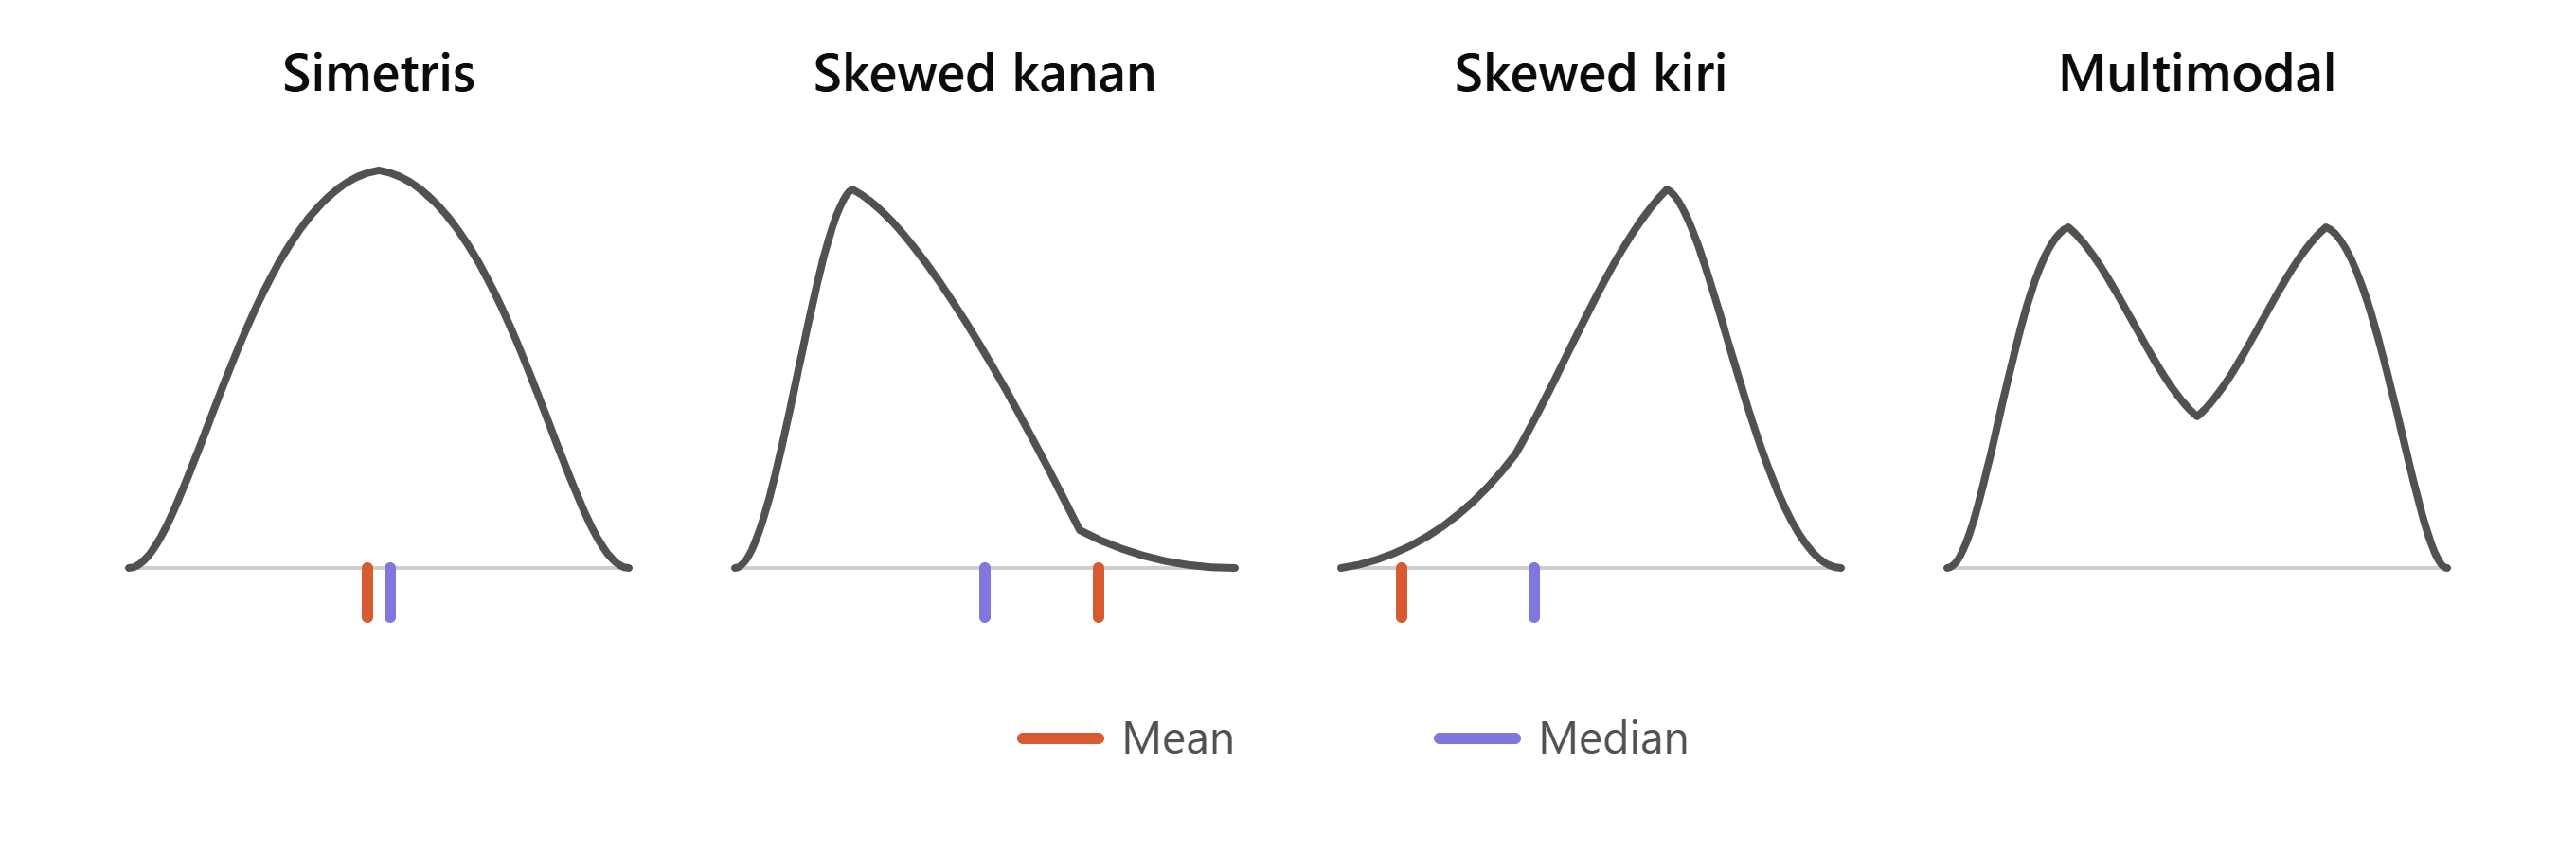

Perhatikan pada diagram: di panel skewed kanan, garis mean (coral) berada di sebelah kanan garis median (ungu) — persis seperti prinsip yang dijelaskan di atas. Di panel skewed kiri, urutannya terbalik. Di panel simetris, keduanya nyaris berimpit. Panel multimodal sengaja tidak diberi penanda mean/median karena keduanya kehilangan makna interpretatifnya di sana.